In [ ]:
#1.Connecting the drive with kitti dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#2. Cloning into OpenPCDet which is from mmdettection and helps us run the pre trained Point Pillards libraray
import os

if not os.path.exists('OpenPCDet'):
    !git clone https://github.com/open-mmlab/OpenPCDet.git
%cd OpenPCDet

Cloning into 'OpenPCDet'...
remote: Enumerating objects: 4175, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 4175 (delta 0), reused 0 (delta 0), pack-reused 4170 (from 2)
Receiving objects: 100% (4175/4175), 4.21 MiB | 33.40 MiB/s, done.
Resolving deltas: 100% (2448/2448), done.
/content/OpenPCDet


Please make sure your KITTI dataset in Google Drive is structured as required by OpenPCDet:
```
OpenPCDet
├── data
│   ├── kitti
│   │   ├── ImageSets
│   │   ├── training
│   │   │   ├── calib & velodyne & label_2 & image_2 & (optional: planes) & (optional: depth_2)
│   │   ├── testing
│   │   │   ├── calib & velodyne & image_2
```
Update the `/content/drive/MyDrive/path_to_kitti` in the next cell to point to your actual KITTI folder in Drive.

In [ ]:
#3.Setting up the environment for execution of the mmdet libray
import os

print("1. Installing CUDA 11.8...")
!apt-get update > /dev/null
!apt-get install -y cuda-toolkit-11-8 > /dev/null
os.environ["CUDA_HOME"] = "/usr/local/cuda-11.8"

print("\n2. Installing PyTorch cu118...")
!pip install torch==2.2.1 torchvision==0.17.1 torchaudio==2.2.1 --index-url https://download.pytorch.org/whl/cu118 > /dev/null

print("\n3. Installing spconv and cumm...")
!pip uninstall -y spconv spconv-cu118 cumm cumm-cu118 > /dev/null
!pip install --upgrade cumm-cu118 spconv-cu118 > /dev/null

# Disable JIT to prevent compilation errors
os.environ["SPCONV_DISABLE_JIT"] = "1"
os.environ["CUMM_DISABLE_JIT"] = "1"

print("\n4. Setting up OpenPCDet...")
if not os.path.exists('/content/OpenPCDet'):
    !git clone https://github.com/open-mmlab/OpenPCDet.git

!pip install tensorboardX easydict pyyaml scikit-image tqdm SharedArray numba > /dev/null
!cd /content/OpenPCDet && pip install av2 && pip install -r requirements.txt > /dev/null
!cd /content/OpenPCDet && python setup.py develop

# Fix for NumPy 2.0 compatibility issues - enforced at the end
print("\nInstalling compatible NumPy version (1.26.4)...")
!pip install "numpy<2.0.0" --force-reinstall > /dev/null
!pip install open3d
print("\n5. Testing spconv import...")
import spconv
print("spconv installed successfully! Version:", spconv.__version__)

1. Installing CUDA 11.8...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
E: Unable to locate package cuda-toolkit-11-8

2. Installing PyTorch cu118...

3. Installing spconv and cumm...

4. Setting up OpenPCDet...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 96.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━


5. Testing spconv import...
spconv installed successfully! Version: 2.3.8


In [ ]:
#3. Setting up the environment
import os
import shutil

# Replace 'path_to_kitti' with your actual path in Drive
drive_kitti_path = '/content/drive/MyDrive/kitti'
local_kitti_path = '/content/OpenPCDet/data/kitti'

os.makedirs('/content/OpenPCDet/data', exist_ok=True)

# Remove existing local_kitti_path if it's not a symlink or if it's a broken symlink
if os.path.exists(local_kitti_path):
    if os.path.islink(local_kitti_path) or os.path.isdir(local_kitti_path):
        print(f"Removing existing {local_kitti_path}")
        if os.path.islink(local_kitti_path):
            os.unlink(local_kitti_path)
        else:
            shutil.rmtree(local_kitti_path)

# Create a new symlink
if not os.path.exists(local_kitti_path):
    os.symlink(drive_kitti_path, local_kitti_path)
    print("Symlink created for KITTI dataset.")
else:
    print("KITTI dataset path already exists and is valid.")

# Verify the symlink content by listing some directories
print(f"Verifying contents of {local_kitti_path}/training:")
if os.path.exists(os.path.join(local_kitti_path, 'training')):
    print(os.listdir(os.path.join(local_kitti_path, 'training')))
else:
    print(f"Directory not found: {local_kitti_path}/training")


Removing existing /content/OpenPCDet/data/kitti
Symlink created for KITTI dataset.
Verifying contents of /content/OpenPCDet/data/kitti/training:
['calib', 'label_2', 'velodyne', 'image_2', 'velodyne_reduced']


In [ ]:
#fix to avoid using JIT as it causes issues while execution.
import os

so3_file_path = '/content/OpenPCDet/pcdet/datasets/argo2/argo2_utils/so3.py'

# Read the content of the file
with open(so3_file_path, 'r') as f:
    lines = f.readlines()

# Modify the lines to comment out @torch.jit.script
modified_lines = []
for line in lines:
    if '@torch.jit.script' in line:
        modified_lines.append('# ' + line)  # Comment out the line
    else:
        modified_lines.append(line)

# Write the modified content back to the file
with open(so3_file_path, 'w') as f:
    f.writelines(modified_lines)

print(f"Modified {so3_file_path} to comment out @torch.jit.script.")

Modified /content/OpenPCDet/pcdet/datasets/argo2/argo2_utils/so3.py to comment out @torch.jit.script.


In [ ]:

import os
cumm_include_path = '/usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include'
current_cplus_include_path = os.environ.get('CPLUS_INCLUDE_PATH', '')
os.environ['CPLUS_INCLUDE_PATH'] = f"{cumm_include_path}:{current_cplus_include_path}"

print(f"CPLUS_INCLUDE_PATH set to: {os.environ['CPLUS_INCLUDE_PATH']}")
local_kitti_path = '/content/OpenPCDet/data/kitti'
imagesets_path = os.path.join(local_kitti_path, 'ImageSets')

print(f"Verifying contents of {imagesets_path}:")
if os.path.exists(imagesets_path):
    print(os.listdir(imagesets_path))
    # Optionally, check if train.txt and val.txt exist
    print(f"Does train.txt exist? {os.path.exists(os.path.join(imagesets_path, 'train.txt'))}")
    print(f"Does val.txt exist? {os.path.exists(os.path.join(imagesets_path, 'val.txt'))}")
else:
    print(f"Directory not found: {imagesets_path}")

CPLUS_INCLUDE_PATH set to: /usr/local/lib/python3.12/dist-packages/cumm/build/core_cc/include:
Verifying contents of /content/OpenPCDet/data/kitti/ImageSets:
['test.txt', 'train.txt', 'val.txt']
Does train.txt exist? True
Does val.txt exist? True


In [ ]:
#evaluation on validation dataset using pretrained pointpillar file
%cd /content/OpenPCDet/tools

# Please download the pre-trained PointPillar weights from OpenPCDet's Model Zoo
# and place them in your Google Drive, then update the path below.
ckpt_path = '/content/drive/MyDrive/kitti/pointrcnn_7870.pth'

# Command to run evaluation on the KITTI validation set.
# Added --save_to_file to save the result.pkl for tracking tasks.
!cd /content/OpenPCDet/tools &&  python test.py --cfg_file cfgs/kitti_models/pointrcnn.yaml --batch_size 4 --ckpt {ckpt_path} --save_to_file

# --- ALTERNATIVELY ---
# If you just want to run inference on a specific point cloud bin file and visualize/get predictions:
#!cd /content/OpenPCDet/tools &&  python demo.py --cfg_file cfgs/kitti_models/pointrcnn.yaml --ckpt {ckpt_path} --data_path ../data/kitti/testing/velodyne/000000.bin


/content/OpenPCDet/tools
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_batch/pointnet2_modules.py:26: SyntaxWarning: invalid escape sequence '\s'
  new_features: (B, npoint, \sum_k(mlps[k][-1])) tensor of the new_features descriptors
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_stack/pointnet2_modules.py:87: SyntaxWarning: invalid escape sequence '\s'
  new_features: (M1 + M2 ..., \sum_k(mlps[k][-1])) tensor of the new_features descriptors
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_stack/pointnet2_modules.py:392: SyntaxWarning: invalid escape sequence '\s'
  new_features: (M1 + M2 ..., \sum_k(mlps[k][-1])) tensor of the new_features descriptors
/content/OpenPCDet/tools/../pcdet/ops/pointnet2/pointnet2_stack/voxel_pool_modules.py:81: SyntaxWarning: invalid escape sequence '\s'
  new_features: (M1 + M2 ..., \sum_k(mlps[k][-1])) tensor of the new_features descriptors
2026-03-20 14:26:26,437   INFO  **********************Start logging****************

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd

def parse_log_and_plot(log_path):
    """
    Parses the log file to extract 3D and BEV AP_R40 metrics and plots them.
    Assumes standard OpenPCDet evaluation output format.
    """
    try:
        with open(log_path, 'r') as f:
            log_content = f.read()
    except FileNotFoundError:
        print(f"Error: Log file not found at {log_path}")
        return

    # Define the specific headers for each class according to AP_R40
    headers = {
        'Car': r'Car AP_R40@0.70, 0.70, 0.70:(.*?)(?=\n\n|\Z)',
        'Pedestrian': r'Pedestrian AP_R40@0.50, 0.50, 0.50:(.*?)(?=\n\n|\Z)',
        'Cyclist': r'Cyclist AP_R40@0.50, 0.50, 0.50:(.*?)(?=\n\n|\Z)'
    }

    metrics_data = []

    # Parse the log content
    for cls, pattern in headers.items():
        cls_match = re.search(pattern, log_content, re.DOTALL)

        if cls_match:
            block = cls_match.group(1)

            # Extract 3d AP
            ap_3d_match = re.search(r"3d\s+AP:([\d\.]+),\s*([\d\.]+),\s*([\d\.]+)", block)
            if ap_3d_match:
                easy, moderate, hard = map(float, ap_3d_match.groups())
                for diff, val in zip(['Easy', 'Moderate', 'Hard'], [easy, moderate, hard]):
                    metrics_data.append({'Class': cls, 'Difficulty': diff, 'AP Type': '3D', 'AP': val})

            # Extract bev AP
            ap_bev_match = re.search(r"bev\s+AP:([\d\.]+),\s*([\d\.]+),\s*([\d\.]+)", block)
            if ap_bev_match:
                easy, moderate, hard = map(float, ap_bev_match.groups())
                for diff, val in zip(['Easy', 'Moderate', 'Hard'], [easy, moderate, hard]):
                    metrics_data.append({'Class': cls, 'Difficulty': diff, 'AP Type': 'BEV', 'AP': val})

    if not metrics_data:
        print("No matching 3D/BEV metrics found in the log file. Please check the log format.")
        return

    df = pd.DataFrame(metrics_data)
    display(df)

    # Plotting
    plt.figure(figsize=(14, 6))

    # Subplot for 3D AP
    plt.subplot(1, 2, 1)
    sns.barplot(data=df[df['AP Type'] == '3D'], x='Class', y='AP', hue='Difficulty', palette='viridis')
    plt.title('3D Average Precision (AP_R40)')
    plt.ylabel('Average Precision (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Subplot for BEV AP
    plt.subplot(1, 2, 2)
    sns.barplot(data=df[df['AP Type'] == 'BEV'], x='Class', y='AP', hue='Difficulty', palette='magma')
    plt.title('BEV Average Precision (AP_R40)')
    plt.ylabel('Average Precision (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Input path here. Change to your actual log file path.
log_file_path = '/content/point_rcnn_log_eval_20260319-142131.txt'

# Find and parse the log file
import glob
matched_files = glob.glob(log_file_path)
if matched_files:
    # Pick the most recent one or the only one
    exact_log_path = matched_files[-1]
    print(f"Found log file: {exact_log_path}")
    parse_log_and_plot(exact_log_path)
else:
    print(f"Could not find log files matching {log_file_path}. Please update the path.")


Could not find log files matching /content/point_rcnn_log_eval_20260319-142131.txt. Please update the path.


Load the GT and predicted data

In [ ]:
import pickle
import glob
import os
import numpy as np

class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'numpy.core.multiarray':
            module = 'numpy._core.multiarray'
        return super().find_class(module, name)

# Load ground truth
gt_path = '/content/OpenPCDet/data/kitti/kitti_infos_val.pkl'
try:
    with open(gt_path, 'rb') as f:
        gt_infos = CustomUnpickler(f).load()
    print(f"Successfully loaded ground truth from {gt_path}")
except FileNotFoundError:
    print(f"Ground truth file {gt_path} not found.")
except Exception as e:
    print(f"Failed to load {gt_path}: {e}")

# Find the prediction results file
result_files = glob.glob('/content/pointrcnn_result.pkl', recursive=True)
pred_path = result_files[0] if result_files else 'results.pkl'

if os.path.exists(pred_path):
    try:
        with open(pred_path, 'rb') as f:
            pred_infos = CustomUnpickler(f).load()
        print(f"Loaded predictions from {pred_path}")
    except Exception as e:
        print(f"Failed to load predictions: {e}")
else:
    print(f"Prediction file {pred_path} not found.")


Successfully loaded ground truth from /content/OpenPCDet/data/kitti/kitti_infos_val.pkl
Loaded predictions from /content/pointrcnn_result.pkl


Define 2D IoU Function

In [ ]:
def calculate_iou_2d(box1, box2):
    """
    Calculate the 2D Intersection over Union (IoU) of two bounding boxes.

    Parameters:
    box1 (list or tuple): [x_min, y_min, x_max, y_max]
    box2 (list or tuple): [x_min, y_min, x_max, y_max]

    Returns:
    float: IoU value
    """
    # Determine the coordinates of the intersection rectangle
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # Calculate the area of intersection rectangle
    intersection_area = max(0, x_right - x_left) * max(0, y_bottom - y_top)

    # Calculate the area of both bounding boxes
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Calculate the union area
    union_area = box1_area + box2_area - intersection_area

    # Compute the Intersection over Union
    if union_area == 0:
        return 0.0

    iou = intersection_area / union_area
    return iou

print("Defined calculate_iou_2d function.")


Defined calculate_iou_2d function.


Extract Prediction Scores and Matches

In [ ]:
def extract_prediction_matches(pred_infos, gt_infos, target_class='Car', iou_threshold=0.5):
    results = []
    num_frames = min(len(pred_infos), len(gt_infos))

    for i in range(num_frames):
        pred = pred_infos[i]
        gt = gt_infos[i]

        if 'name' in pred and 'bbox' in pred and 'score' in pred:
            pred_names = pred['name']
            pred_bboxes = pred['bbox']
            pred_scores = pred['score']
        else:
            continue

        class_mask = pred_names == target_class
        pred_bboxes_cls = pred_bboxes[class_mask]
        pred_scores_cls = pred_scores[class_mask]

        if 'annos' in gt and 'name' in gt['annos'] and 'bbox' in gt['annos']:
            gt_names = gt['annos']['name']
            gt_bboxes = gt['annos']['bbox']
        else:
            gt_names = np.array([])
            gt_bboxes = np.array([])

        gt_class_mask = gt_names == target_class
        gt_bboxes_cls = gt_bboxes[gt_class_mask]

        matched_gt = np.zeros(len(gt_bboxes_cls), dtype=bool)

        for pred_box, score in zip(pred_bboxes_cls, pred_scores_cls):
            best_iou = 0.0
            best_gt_idx = -1

            for j, gt_box in enumerate(gt_bboxes_cls):
                if matched_gt[j]:
                    continue
                iou = calculate_iou_2d(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j

            if best_iou >= iou_threshold and best_gt_idx != -1:
                matched_gt[best_gt_idx] = True
                results.append({'score': score, 'tp': 1, 'fp': 0, 'iou': best_iou})
            else:
                results.append({'score': score, 'tp': 0, 'fp': 1, 'iou': best_iou})

    return results

prediction_matches = extract_prediction_matches(pred_infos, gt_infos, target_class='Car', iou_threshold=0.5)
print(f"Extracted {len(prediction_matches)} prediction matches.")
if len(prediction_matches) > 0:
    print(f"Sample match: {prediction_matches[0]}")

Extracted 18408 prediction matches.
Sample match: {'score': np.float32(0.48604017), 'tp': 0, 'fp': 1, 'iou': 0.0}


In [ ]:
import numpy as np

def evaluate_class_2d(target_class, prediction_matches, gt_infos):
    # 1. Calculate total ground truth boxes for the target class
    total_gt = 0
    for gt in gt_infos:
        if 'annos' in gt and 'name' in gt['annos']:
            gt_names = gt['annos']['name']
            total_gt += np.sum(gt_names == target_class)

    # Handle edge case: no ground truth or predictions
    if total_gt == 0 or len(prediction_matches) == 0:
        return {
            'AP': 0.0,
            'optimal_threshold': 0.0,
            'optimal_precision': 0.0,
            'optimal_recall': 0.0,
            'optimal_f1': 0.0,
            'optimal_avg_iou': 0.0,
            'recall_array': np.array([]),
            'precision_array': np.array([])
        }

    # 2. Sort prediction matches by score descending
    sorted_matches = sorted(prediction_matches, key=lambda x: x['score'], reverse=True)

    # 3. Extract tp, fp, scores, and ious
    tp_array = np.array([m['tp'] for m in sorted_matches])
    fp_array = np.array([m['fp'] for m in sorted_matches])
    scores_array = np.array([m['score'] for m in sorted_matches])

    # 4. Compute cumulative tp and fp
    cum_tp = np.cumsum(tp_array)
    cum_fp = np.cumsum(fp_array)

    # 5. Calculate precision and recall
    precision = cum_tp / (cum_tp + cum_fp)
    precision[np.isnan(precision)] = 0
    recall = cum_tp / total_gt

    # Make precision monotonically decreasing for AP calculation
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])

    # Calculate AP
    i = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1])

    # 6. Compute F1-scores and find optimal threshold
    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores = np.nan_to_num(f1_scores, nan=0.0)
    optimal_idx = np.argmax(f1_scores)

    optimal_threshold = scores_array[optimal_idx]
    optimal_precision = precision[optimal_idx]
    optimal_recall = recall[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]

    # 7. Calculate average IoU for true positives >= optimal threshold
    filtered_matches = [m for m in sorted_matches if m['score'] >= optimal_threshold and m['tp'] == 1]
    tp_ious = [m['iou'] for m in filtered_matches]
    optimal_avg_iou = np.mean(tp_ious) if tp_ious else 0.0

    # 8. Return metrics dictionary
    return {
        'AP': ap,
        'optimal_threshold': optimal_threshold,
        'optimal_precision': optimal_precision,
        'optimal_recall': optimal_recall,
        'optimal_f1': optimal_f1,
        'optimal_avg_iou': optimal_avg_iou,
        'recall_array': recall,
        'precision_array': precision
    }

print("Defined evaluate_class_2d function.")


Defined evaluate_class_2d function.


Evaluating class: Car...
Evaluating class: Cyclist...
Evaluating class: Pedestrian...


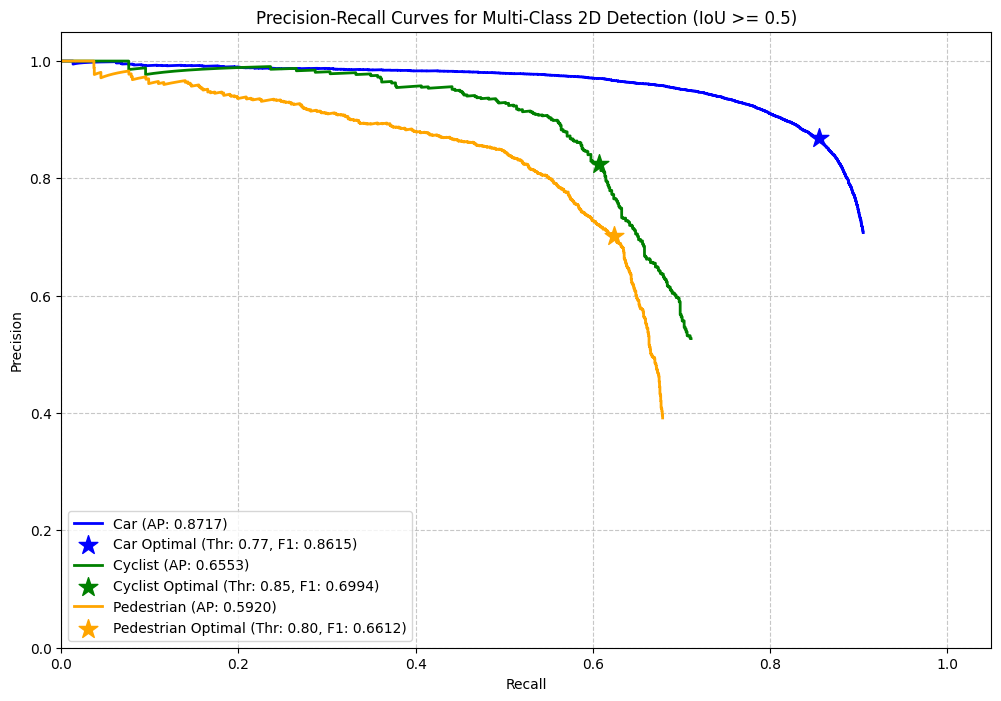


--- Multi-Class 2D Detection Summary (IoU >= 0.5) ---

Class: Car
  Average Precision (AP): 0.8717
  Optimal Confidence Threshold: 0.7723
  Precision at Optimal: 0.8681
  Recall at Optimal: 0.8550
  Max F1-score: 0.8615
  Average IoU at Optimal: 0.8759

Class: Cyclist
  Average Precision (AP): 0.6553
  Optimal Confidence Threshold: 0.8536
  Precision at Optimal: 0.8250
  Recall at Optimal: 0.6069
  Max F1-score: 0.6994
  Average IoU at Optimal: 0.8184

Class: Pedestrian
  Average Precision (AP): 0.5920
  Optimal Confidence Threshold: 0.7965
  Precision at Optimal: 0.7025
  Recall at Optimal: 0.6246
  Max F1-score: 0.6612
  Average IoU at Optimal: 0.6901


In [ ]:
import matplotlib.pyplot as plt

classes_to_evaluate = ['Car', 'Cyclist', 'Pedestrian']
all_class_metrics = {}

plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'orange']

for idx, cls in enumerate(classes_to_evaluate):
    print(f"Evaluating class: {cls}...")
    # Extract matches for the specific class
    matches = extract_prediction_matches(pred_infos, gt_infos, target_class=cls, iou_threshold=0.5)

    # Evaluate metrics
    metrics = evaluate_class_2d(cls, matches, gt_infos)
    all_class_metrics[cls] = metrics

    if metrics['recall_array'].size > 0 and metrics['precision_array'].size > 0:
        # Plot PR curve
        plt.plot(metrics['recall_array'], metrics['precision_array'], color=colors[idx],
                 label=f"{cls} (AP: {metrics['AP']:.4f})", linewidth=2)

        # Highlight optimal threshold
        plt.scatter(metrics['optimal_recall'], metrics['optimal_precision'], marker='*', s=200, color=colors[idx], zorder=5,
                    label=f"{cls} Optimal (Thr: {metrics['optimal_threshold']:.2f}, F1: {metrics['optimal_f1']:.4f})")
    else:
        print(f"No valid data to plot for {cls}.")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Multi-Class 2D Detection (IoU >= 0.5)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.show()

# Print summary
print("\n--- Multi-Class 2D Detection Summary (IoU >= 0.5) ---")
for cls, m in all_class_metrics.items():
    print(f"\nClass: {cls}")
    print(f"  Average Precision (AP): {m['AP']:.4f}")
    print(f"  Optimal Confidence Threshold: {m['optimal_threshold']:.4f}")
    print(f"  Precision at Optimal: {m['optimal_precision']:.4f}")
    print(f"  Recall at Optimal: {m['optimal_recall']:.4f}")
    print(f"  Max F1-score: {m['optimal_f1']:.4f}")
    print(f"  Average IoU at Optimal: {m['optimal_avg_iou']:.4f}")